##  **Healthcare Analytics for Doctor Visits**
**Domain** - Healthcare

---



**Introduction** - This notebook explores a healthcare dataset to analyze factors influencing doctor visits. By examining demographic information, health status indicators, and healthcare access details, this project aims to uncover patterns and relationships that can inform healthcare resource allocation and policy development. Through various data analysis and visualization techniques, we will gain insights into patient behavior and healthcare utilization.

---



## Problem Statement

Healthcare providers and policymakers face the challenge of optimizing resource allocation and improving patient outcomes. A key aspect of this is understanding the factors that influence doctor visits. Predicting patient visit frequency can help in proactive resource management, targeted interventions, and personalized healthcare planning. This dataset provides an opportunity to explore the demographics, health status, and other related factors that contribute to the number of doctor visits, thereby addressing the challenge of efficiently delivering healthcare services.

---



## Project Description

This project aims to analyze a healthcare dataset containing information on patient demographics (gender, age, income), health status (illness, chronic conditions), and healthcare access (private insurance, reduced health). The primary goal is to understand the relationships between these variables and the number of doctor visits. Through exploratory data analysis (EDA), univariate and multivariate visualizations, we seek to identify patterns, correlations, and key determinants of doctor visit frequency. The insights gained will help in developing strategies for healthcare planning and resource optimization.

---



## End Users

*   **Healthcare Administrators:** To optimize staffing, manage patient flow, and allocate resources more efficiently.
*   **Policymakers and Public Health Officials:** To formulate evidence-based policies, design targeted health programs, and address disparities in healthcare access.
*   **Medical Researchers:** To identify risk factors for increased doctor visits and contribute to a deeper understanding of health-seeking behaviors.
*   **Insurance Providers:** To better understand factors influencing healthcare utilization and potentially refine insurance plans or risk assessments.

---



## Technology Used

*   **Python:** The primary programming language for data analysis.
*   **Pandas:** For data manipulation and analysis.
*   **Matplotlib & Seaborn:** For data visualization and creating informative plots.
*   **Jupyter/Colab Notebooks:** For interactive data exploration and documentation.

---



In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

In [9]:
print("No. of Rows in the dateset:",df.shape[1])
print("No. of Columns in the dateset:",df.shape[1])

No. of Rows in the dateset: 13
No. of Columns in the dateset: 13


In [4]:
print("The Shape of the Dataset:",df.shape)

The Shape of the Dataset: (5190, 13)


In [5]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [6]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [10]:
print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))


Missing values:


,Missing Values
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


In [11]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,5190.0,NaN,NaN,NaN,2595.5,1498.368279,1.0,1298.25,2595.5,3892.75,5190.0
visits,5190.0,NaN,NaN,NaN,0.301734,0.798134,0.0,0.0,0.0,0.0,9.0
gender,5190,2,female,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5190.0,NaN,NaN,NaN,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,NaN,NaN,NaN,0.58316,0.368907,0.0,0.25,0.55,0.9,1.5
illness,5190.0,NaN,NaN,NaN,1.431985,1.384152,0.0,0.0,1.0,2.0,5.0
reduced,5190.0,NaN,NaN,NaN,0.86185,2.887628,0.0,0.0,0.0,0.0,14.0
health,5190.0,NaN,NaN,NaN,1.217534,2.124266,0.0,0.0,0.0,2.0,12.0
private,5190,2,no,2892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freepoor,5190,2,no,4968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Univariate Analysis

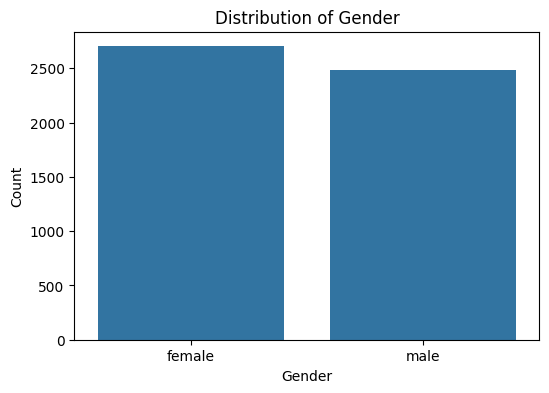

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

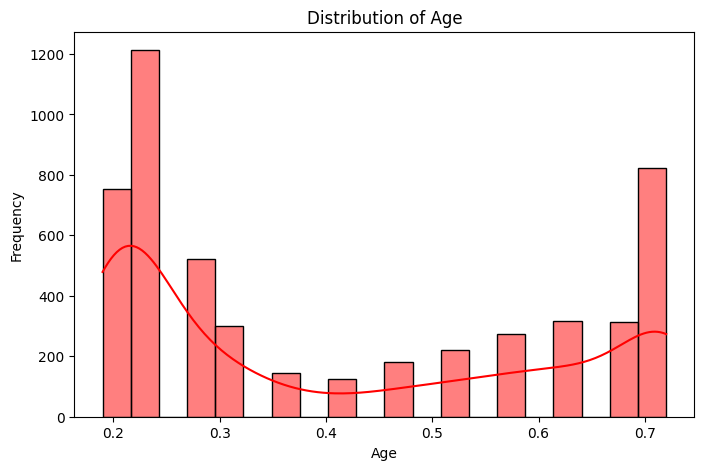

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color="red")
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

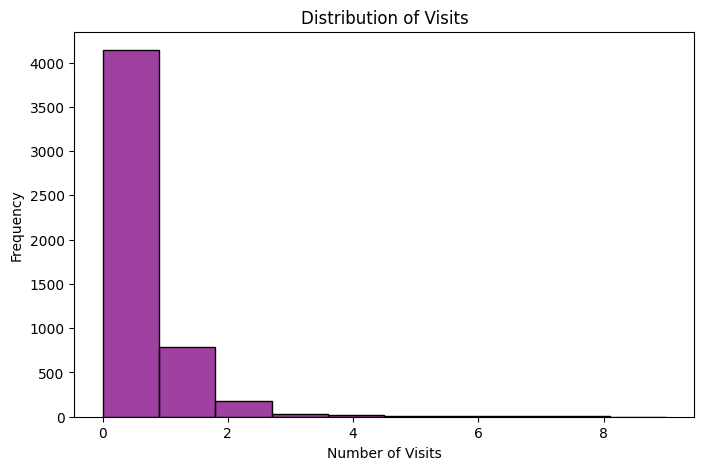

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=df['visits'].nunique(), kde=False, color="purple")
plt.title('Distribution of Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Frequency')
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


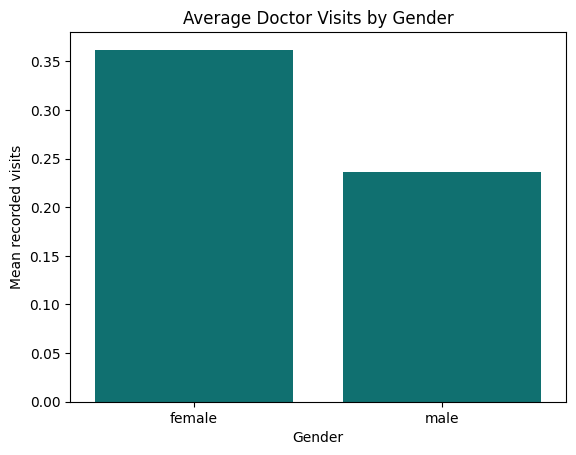

In [15]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


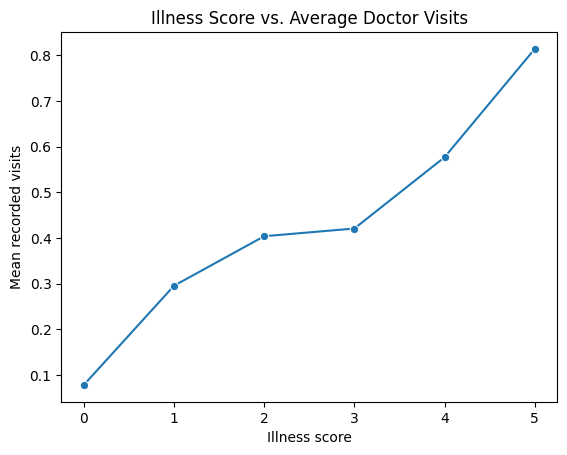

In [16]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(illness_analysis)

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

### Multivariate Analysis

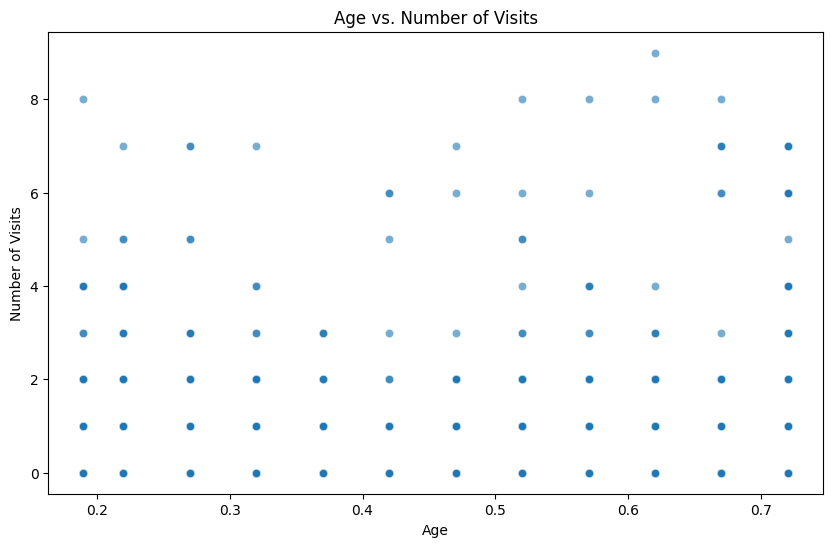

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', data=df, alpha=0.6)
plt.title('Age vs. Number of Visits')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

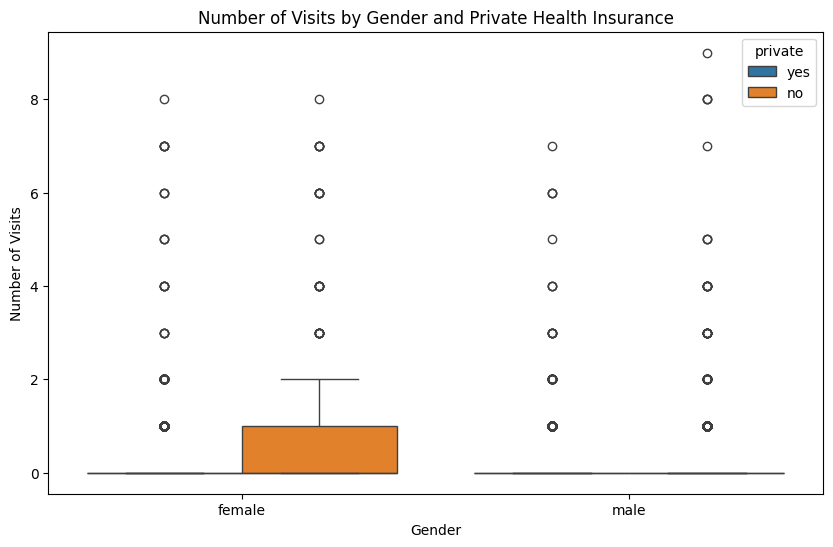

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='visits', hue='private', data=df)
plt.title('Number of Visits by Gender and Private Health Insurance')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

## Thank You Statement

Thank you for the opportunity to analyze this valuable healthcare dataset. The insights derived from this exploration can significantly contribute to understanding patient behavior and improving healthcare service delivery. We hope these findings are useful for stakeholders in the healthcare sector.

---

